In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import joblib



In [2]:
row_data=pd.read_csv("hand_landmarks_data.csv")
# col_names=['x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'x3', 'y3', 'z3', 'x4', 'y4', 'z4',
#        'x5', 'y5', 'z5', 'x6', 'y6', 'z6', 'x7', 'y7', 'z7', 'x8', 'y8', 'z8',
#        'x9', 'y9', 'z9', 'x10', 'y10', 'z10', 'x11', 'y11', 'z11', 'x12',
#        'y12', 'z12', 'x13', 'y13', 'z13', 'x14', 'y14', 'z14', 'x15', 'y15',
#        'z15', 'x16', 'y16', 'z16', 'x17', 'y17', 'z17', 'x18', 'y18', 'z18',
#        'x19', 'y19', 'z19', 'x20', 'y20', 'z20', 'x21', 'y21', 'z21', 'label']


In [3]:
row_data.shape

(25675, 64)

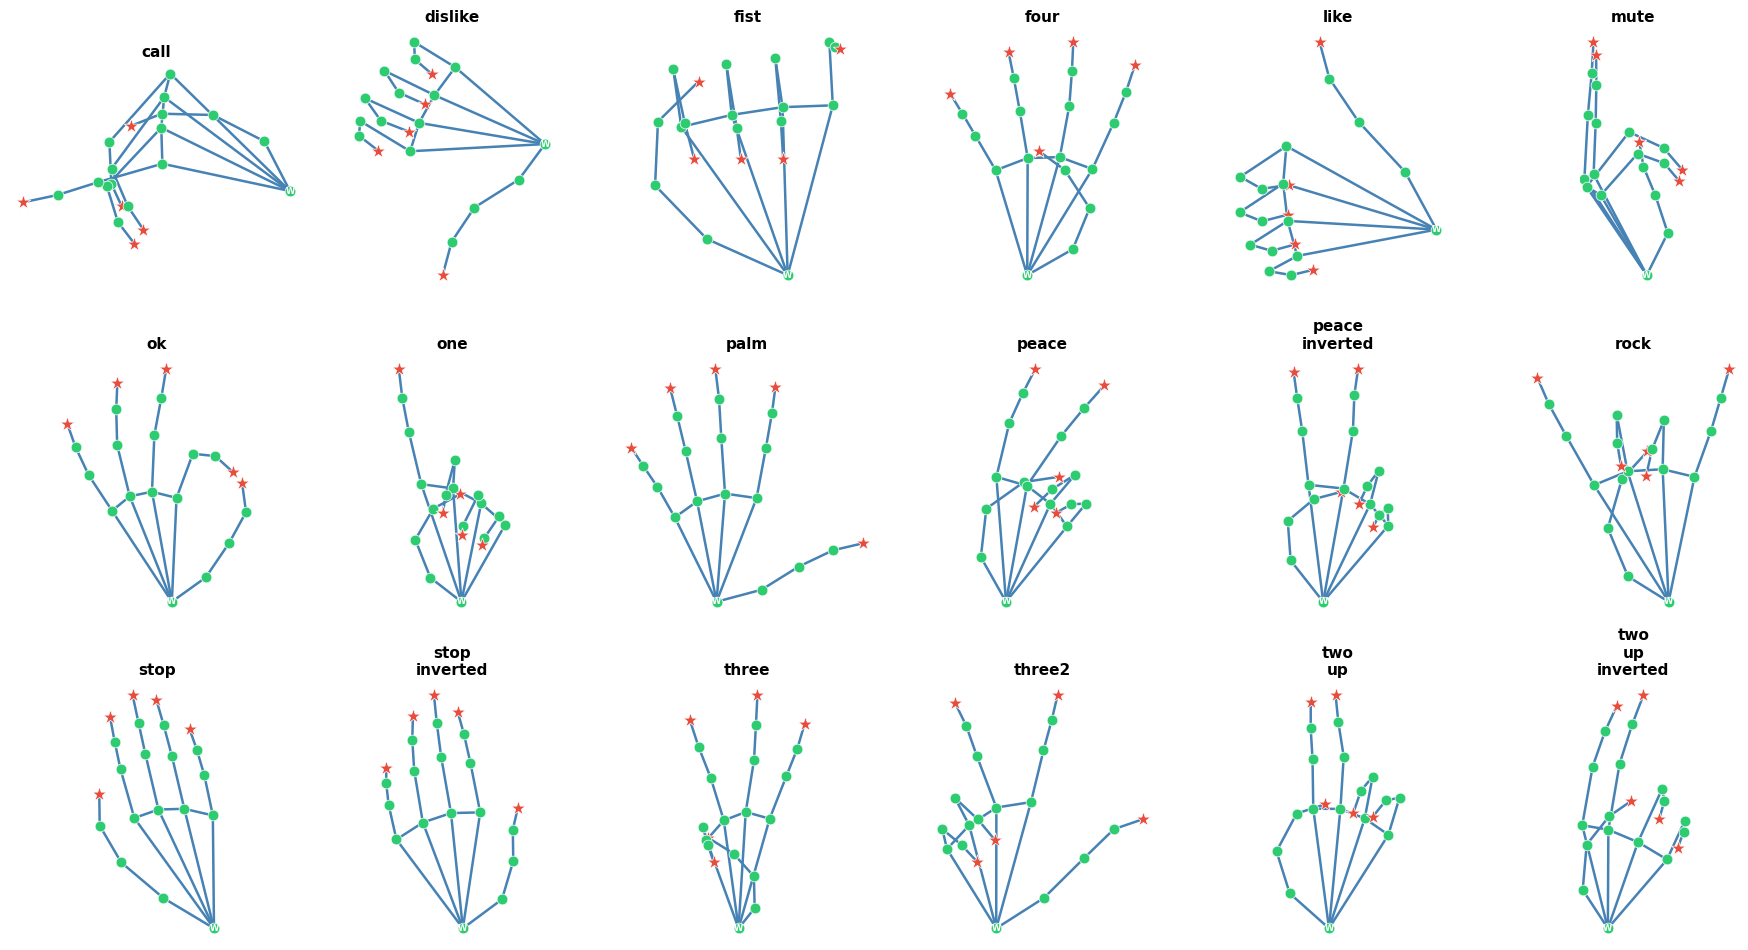

In [4]:

CONNECTIONS = [
    (1, 2),  (2, 3),  (3, 4),  (4, 5),    # Thumb
    (1, 6),  (6, 7),  (7, 8),  (8, 9),    # Index
    (1, 10), (10,11), (11,12), (12,13),   # Middle
    (1, 14), (14,15), (15,16), (16,17),   # Ring
    (1, 18), (18,19), (19,20), (20,21),   # Pinky
    (6, 10), (10,14), (14,18),            # Palm
]


FINGERTIPS = {5, 9, 13, 17, 21}

def draw_hand(ax, row, title):
    """Draw one hand skeleton from a raw (un-normalised) dataset row."""
    
    coords = np.array([[row[f'x{i}'], row[f'y{i}'], row[f'z{i}']]
                       for i in range(1, 22)])
    x, y = coords[:, 0], coords[:, 1]

    
    for s, e in CONNECTIONS:
        ax.plot([x[s-1], x[e-1]], [y[s-1], y[e-1]],
                color='steelblue', linewidth=1.8, zorder=1)

    
    for idx in range(21):
        landmark_num = idx + 1   
        color  = '#e74c3c' if landmark_num in FINGERTIPS else '#2ecc71'
        marker = '*'            if landmark_num in FINGERTIPS else 'o'
        size   = 120            if landmark_num in FINGERTIPS else 60
        ax.scatter(x[idx], y[idx], c=color, s=size, marker=marker,
                   zorder=2, edgecolors='white', linewidths=0.5)

 
    ax.annotate('W', (x[0], y[0]), fontsize=6, ha='center', va='center',
                color='white', fontweight='bold', zorder=3)

    ax.set_title(title, fontsize=11, fontweight='bold', pad=6)
    ax.set_aspect('equal')
    ax.invert_yaxis()          
    ax.axis('off')


all_classes   = sorted(row_data['label'].unique())
n_classes     = len(all_classes)                  
n_cols        = 6
n_rows        = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 3, n_rows * 3.2))
axes = axes.flatten()

for ax, gesture in zip(axes, all_classes):
    sample = row_data[row_data['label'] == gesture].iloc[0]
    draw_hand(ax, sample, gesture.replace('_', '\n'))


for ax in axes[n_classes:]:
    ax.set_visible(False)

#

plt.tight_layout()
plt.show()


In [5]:
def normalize_landmarks(row):
    """
    Normalize hand landmarks:
    1. Recenter to wrist (landmark 0)
    2. Scale by middle finger tip distance (landmark 13)
    
    Args:
        row: DataFrame row containing landmark coordinates
    
    Returns:
        Normalized landmark coordinates
    """
    
    feature_cols = [col for col in row_data.columns if col != 'label']
    features = row[feature_cols].values
    
   
    landmarks = features.reshape(21, 3)
    
    
    wrist = landmarks[0].copy()
    
    landmarks[:, 0] -= wrist[0]  # x coordinates
    landmarks[:, 1] -= wrist[1]  # y coordinates
    
    
   
    middle_finger_tip = landmarks[13].copy()
    
  
    scale = np.sqrt(middle_finger_tip[0]**2 + middle_finger_tip[1]**2)
    
    if scale > 1e-6:
        landmarks[:, 0] /= scale  # Normalize x
        landmarks[:, 1] /= scale  # Normalize y
    
    
    return landmarks.flatten()


print("Normalizing landmarks...")
feature_cols = [col for col in row_data.columns if col != 'label']
normalized_features = row_data.apply(normalize_landmarks, axis=1)
normalized_df = pd.DataFrame(normalized_features.tolist(), columns=feature_cols)
normalized_df['label'] = row_data['label'].values

print("Normalization complete!")
print(f"Normalized data shape: {normalized_df.shape}")

Normalizing landmarks...
Normalization complete!
Normalized data shape: (25675, 64)


In [6]:

features = normalized_df.drop('label', axis=1).values
labels = normalized_df['label'].values
features_train,features_test ,labels_train,labels_test=train_test_split(features,labels,test_size=0.2,random_state=42,stratify=labels)





In [7]:
def Train_Evaluate_model(model_name,model,param_grid,features_train,features_test ,labels_train,labels_test):
    grid=GridSearchCV(model,param_grid,cv=5)
    mlflow.set_experiment(f"{model_name}_Experiment")
    with mlflow.start_run(run_name=f"{model_name}_GridSearchCV") as run:
        grid.fit(features_train,labels_train)
        best_model=grid.best_estimator_
        
        labels_predect=best_model.predict(features_test)
        acc = accuracy_score(labels_test, labels_predect)
        prec = precision_score(labels_test, labels_predect, average='weighted', zero_division=0)
        rec = recall_score(labels_test, labels_predect, average='weighted', zero_division=0)
        f1 = f1_score(labels_test, labels_predect, average='weighted', zero_division=0)
        
        #####################################################################33
        #mlflow
        mlflow.log_params(grid.best_params_)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)
        mlflow.log_metric("f1_score", f1)
        #LOG Model
        mlflow.sklearn.log_model(best_model,"model")
        print(f"Run: {run.info.run_id}")
        print(f"Best Params: {grid.best_params_}")
        print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-score: {f1:.4f}")
        
    return best_model


In [8]:
# SVM
svm_params = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01], 'kernel': ['rbf']}

# KNN
knn_params = {'n_neighbors': [3,5,7], 'weights': ['uniform','distance'], 'metric': ['euclidean','manhattan']}

# Random Forest
rf_params = {'n_estimators':[100,200], 'max_depth':[None,10,20], 'min_samples_split':[2,5]}




In [9]:
best_svm = Train_Evaluate_model("SVM", SVC(), svm_params, features_train,features_test ,labels_train,labels_test)

2026/02/27 14:19:11 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/27 14:19:11 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/27 14:19:11 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/27 14:19:11 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/27 14:19:11 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/27 14:19:11 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/27 14:19:12 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/27 14:19:12 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/02/27 14:19:12 INFO mlflow.tracking.fluent: Experiment with name 'SVM_Experiment' does not exist. Creating a new experiment.
2026/02/27 14:25:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\Atif\AppData\Local\Programs\Python\

Run: 49329ca1ccdf4659890489ca4b8c06f7
Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 0.9860, Precision: 0.9861, Recall: 0.9860, F1-score: 0.9860


In [10]:

best_knn = Train_Evaluate_model("KNN", KNeighborsClassifier(), knn_params, features_train,features_test ,labels_train,labels_test)



2026/02/27 14:25:49 INFO mlflow.tracking.fluent: Experiment with name 'KNN_Experiment' does not exist. Creating a new experiment.
c:\Users\Atif\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\Atif\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\Atif\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\Atif\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py", line 450, in score
    return super().score(X, y, sample_w

Run: cb33f61d629245dc865c018da23c2f06
Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Accuracy: 0.9794, Precision: 0.9795, Recall: 0.9794, F1-score: 0.9794


In [11]:
best_rf = Train_Evaluate_model("RandomForest", RandomForestClassifier(), rf_params, features_train,features_test ,labels_train,labels_test)


2026/02/27 14:26:33 INFO mlflow.tracking.fluent: Experiment with name 'RandomForest_Experiment' does not exist. Creating a new experiment.
2026/02/27 14:47:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\Atif\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


Run: 2520fda43004408eb2ac3e0df4bca42b
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 0.9786, Precision: 0.9787, Recall: 0.9786, F1-score: 0.9786


In [12]:
import joblib

joblib.dump(best_svm, "svm_hand_model.pkl")
classes = best_svm.classes_


label_encoder = LabelEncoder()
label_encoder.fit(classes)


joblib.dump(label_encoder, "label_encoder.pkl")

print("Label encoder created and saved!")
print("Classes:", label_encoder.classes_)




Label encoder created and saved!
Classes: ['call' 'dislike' 'fist' 'four' 'like' 'mute' 'ok' 'one' 'palm' 'peace'
 'peace_inverted' 'rock' 'stop' 'stop_inverted' 'three' 'three2' 'two_up'
 'two_up_inverted']
